In [1]:
import keras
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
digits = keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = digits.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X_train = X_train/255
X_test = X_test/255

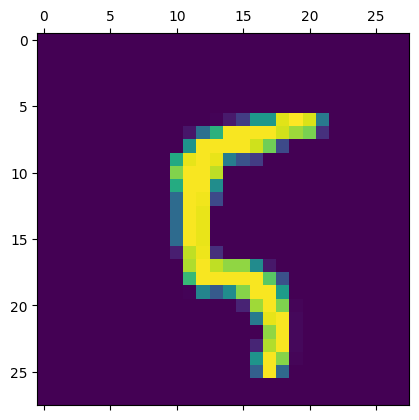

In [6]:
plt.matshow(X_train[100])

In [7]:
y_train[100]

np.uint8(5)

In [8]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.Dense(20, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │        15,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,910 (62.15 KB)

 Trainable params: 15,910 (62.15 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(loss="sparse_categorical_crossentropy", # sparse_categorical_crossentropy
              optimizer="adam",
              metrics=["accuracy"])

In [11]:
model.fit(X_train, y_train)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8905 - loss: 0.3983


In [12]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9323 - loss: 0.2398


[0.23984287679195404, 0.9322999715805054]

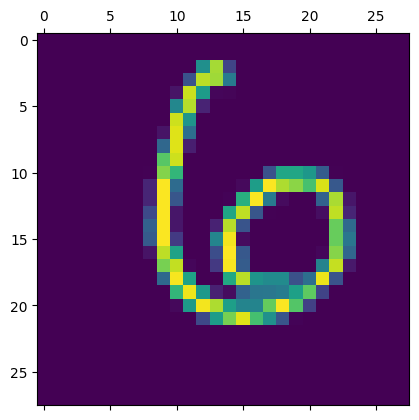

In [13]:
plt.matshow(X_test[100])

In [14]:
yp = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [15]:
yp[0]

array([2.3227833e-04, 4.4897542e-06, 1.0909552e-04, 6.6457526e-04,
       2.4237588e-05, 3.6121030e-05, 4.2055854e-07, 9.9840719e-01,
       2.7500064e-05, 4.9422070e-04], dtype=float32)

In [16]:
np.argmax(yp[0])

np.int64(7)